# Notebook 3: Comparison

Now that notebooks 1 and 2 have each produced an optimum on the same
operating envelope, this notebook puts the two side by side. It also
validates both models against measured experimental data.

**What this notebook produces**

- `data/IEEETIE_machine2_correction.pkl` — predicted torque of the
  neural model **on the baseline (analytical-optimal) currents**.
  Useful to see where the two models most disagree.
- `data/IEEETIE_machine2_recalculated.pkl` — currents re-optimized by
  the neural model starting from the baseline currents as warm starts.
  Used to compute Joule-loss savings.
- Four diagnostic plots: residual torque error, Joule-loss reduction,
  current-trajectory differences, and measured-vs-predicted torque
  scatter for both models.

**Prerequisites**

- `data/IEEETIE_machine2_baseline.pkl` from notebook 1.
- `data/IEEETIE_machine2_compensated.pkl` from notebook 2.
- The trained NTM checkpoint (same as notebook 2).
- `data/aggregated_file_means.csv` — measured torque at known DQ current
  operating points, used for the experimental validation in the last
  section.

## 0. Imports and paths

In [10]:
import os
import pickle
import sys

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

root_dir = os.path.abspath("..")
data_dir = os.path.join(root_dir, "data")
weights_dir = os.path.join(root_dir, "weights")
if root_dir not in sys.path:
    sys.path.append(root_dir)

from current_setpoints.parameters import Flux_IEEEMachine2, IEEEMachine2
from current_setpoints.simulation import Transform
from current_setpoints.optimization import (
    ModelAnalytical,
    ModelNeural,
    MotorOptimizer,
    calculate_grid,
    get_correction_grid,
)
from current_setpoints.utils import load_aggregated_csv_data
from current_setpoints.utils.neural import load_neural_model
from current_setpoints.utils.plotting import (
    plot_current_trajectories_split,
    plot_global_performance,
    plot_joule_losses_reduction,
    plot_residual_torque_error,
)

## 1. Setup

Same machine, flux, transform, and trained NTM as in the previous
notebooks. We need both models here — analytical for measuring
residuals against the neural prediction, neural for the recalculated
grid and the measured-data comparison.

In [11]:
machine = IEEEMachine2()
NMAX = 1800
machine.set_max_pars(curr_max=30.0, volt_max=13.0, omega_max=NMAX)

flux = Flux_IEEEMachine2()
transform = Transform(machine=machine, flux=flux, add_volt_0=False)

DEVICE = torch.device("cpu")
INPUT_SIZE = 5
OPTIMAL_HIDDEN_SIZE = 12

neural_net, scaler = load_neural_model(
    weights_path=os.path.join(weights_dir, "NTM_Weights.pth"),
    scaler_path=os.path.join(weights_dir, "NTM_Scaler.npy"),
    hidden_size=OPTIMAL_HIDDEN_SIZE,
    input_size=INPUT_SIZE,
    device=DEVICE,
)

analytical_model = ModelAnalytical(machine=machine, flux=flux)
neural_model = ModelNeural(
    machine=machine,
    flux=flux,
    neural_model=neural_net,
    scaler=scaler,
    device=DEVICE,
)

solver_opts_neural = {"disp": False, "ftol": 1e-5, "maxiter": 2500, "eps": 1e-4}
neural_optimizer = MotorOptimizer(model=neural_model, opts=solver_opts_neural)

## 2. Loading the upstream grids

If either pickle is missing, the corresponding upstream notebook hasn't
been run. Re-run notebook 1 for the baseline and notebook 2 for the
compensated grid before continuing.

In [12]:
baseline_path = os.path.join(data_dir, "IEEETIE_machine2_baseline.pkl")
compensated_path = os.path.join(data_dir, "IEEETIE_machine2_compensated.pkl")

for p in (baseline_path, compensated_path):
    if not os.path.isfile(p):
        raise FileNotFoundError(
            f"Required input missing: {p}. Run the appropriate upstream "
            f"notebook (1 for baseline, 2 for compensated) before this one."
        )

with open(baseline_path, "rb") as f:
    baseline_grid = pickle.load(f)

with open(compensated_path, "rb") as f:
    compensated_grid = pickle.load(f)

print("Loaded baseline and compensated grids.")

Loaded baseline and compensated grids.


## 3. The correction grid

Conceptually: "what torque does the neural model predict for the
currents that the analytical optimizer chose?" `get_correction_grid`
walks the baseline grid cell by cell and runs the baseline currents
through the neural model, producing a `grid_torq_neural` field.

The difference between the **commanded** torque (the cell's `y`
coordinate, what the analytical model thought it was producing) and
the **predicted** torque (what the neural model says those currents
actually produce) is the per-cell model disagreement.

This step is cheap — no optimization, just forward passes.

> **Pickle safety.** Loads from disk if the file exists; otherwise
> computes and saves.

In [13]:
correction_path = os.path.join(data_dir, "IEEETIE_machine2_correction.pkl")

if os.path.isfile(correction_path):
    print(f"Loading existing correction grid from '{correction_path}'...")
    with open(correction_path, "rb") as f:
        correction_grid = pickle.load(f)
else:
    print("Computing correction grid...")
    correction_grid = get_correction_grid(
        dict_grid=baseline_grid,
        model=neural_model,
    )
    with open(correction_path, "wb") as f:
        pickle.dump(correction_grid, f)
    print(f"Saved to '{correction_path}'.")

Loading existing correction grid from 'c:\Users\matas\Desktop\CurrentSetpoints\data\IEEETIE_machine2_correction.pkl'...


## 4. The recalculated grid

This is `calculate_grid` again, but in `"recalculated"` mode: it takes
the correction grid as input and, at every cell, re-runs the
minimum-current optimizer with the **baseline currents as warm starts**
and the **neural-predicted torque as the target**. The result is a
neural-optimal current set for the torques the neural model claims the
baseline produces.

Warm-starting from the baseline currents makes SLSQP converge much
faster than the from-scratch sweep in notebook 2, so this is roughly
as fast as the baseline grid.

> **Pickle safety.** Same as above.

In [14]:
recalc_path = os.path.join(data_dir, "IEEETIE_machine2_recalculated.pkl")

if os.path.isfile(recalc_path):
    print(f"Loading existing recalculated grid from '{recalc_path}'...")
    with open(recalc_path, "rb") as f:
        recalc_grid = pickle.load(f)
else:
    print("Computing recalculated grid. Warm-started from baseline currents...")
    grid_opts = {"n_torq": 201, "n_omega": 201, "torq_min": 0.0, "omega_min": 0.0}
    recalc_grid = calculate_grid(
        optimizer=neural_optimizer,
        transform=transform,
        opts=grid_opts,
        mode="recalculated",
        dict_grid_corr=correction_grid,
    )
    with open(recalc_path, "wb") as f:
        pickle.dump(recalc_grid, f)
    print(f"Saved to '{recalc_path}'.")

Loading existing recalculated grid from 'c:\Users\matas\Desktop\CurrentSetpoints\data\IEEETIE_machine2_recalculated.pkl'...


## 5. Residual torque error

`plot_residual_torque_error` colours each cell by the difference
between commanded torque (analytical baseline) and neural-predicted
torque on the same currents. Bright red regions are where the two
models most disagree — typically the regions where the analytical
model's assumptions (linear flux, neglected harmonics) break down most.

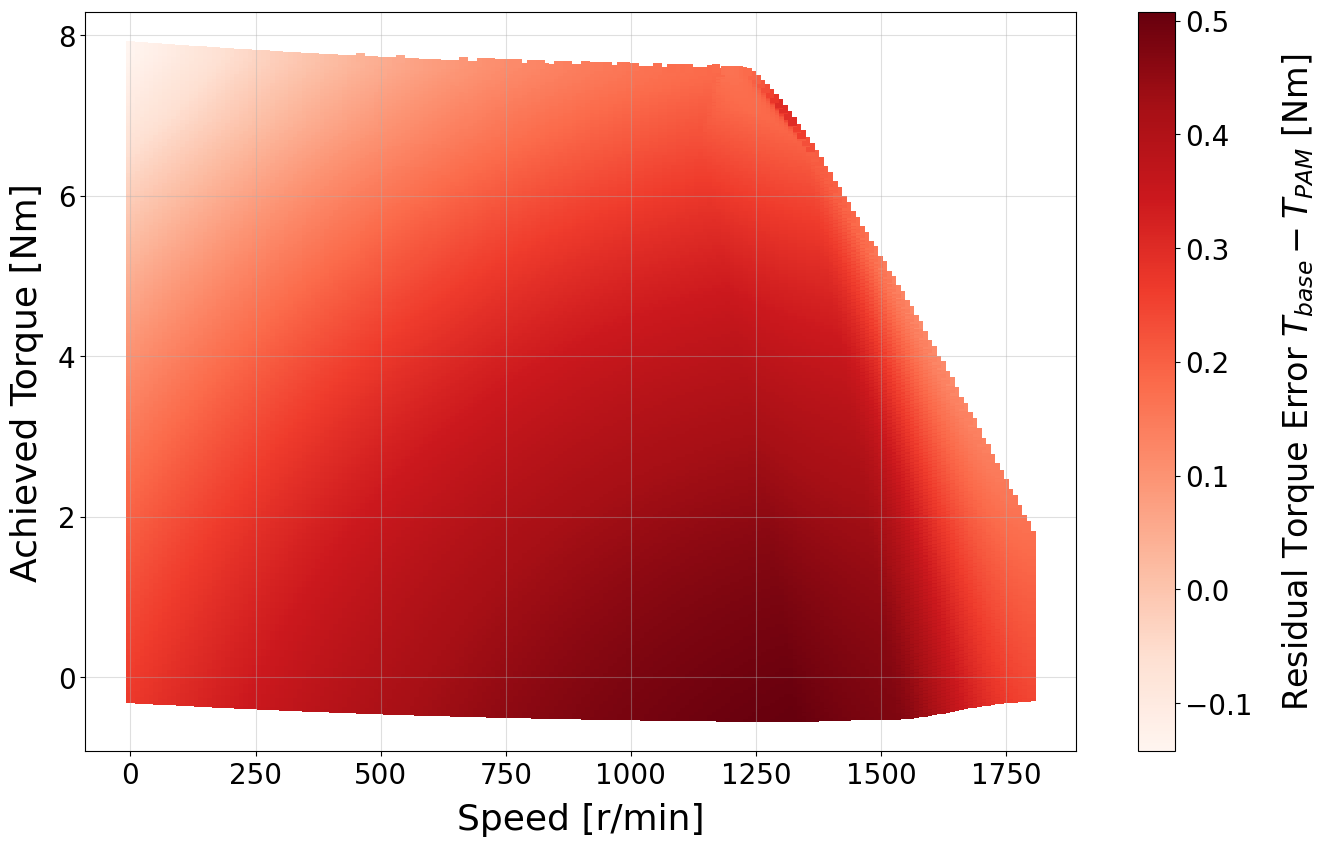

In [15]:
plot_residual_torque_error(correction_grid, machine)

## 6. Joule-loss reduction

For the same neural-predicted torque targets, the recalculated grid
needs less current than the baseline grid, because the neural
optimizer can exploit physics the analytical optimizer didn't account
for. `plot_joule_losses_reduction` shows the per-cell savings in
watts.

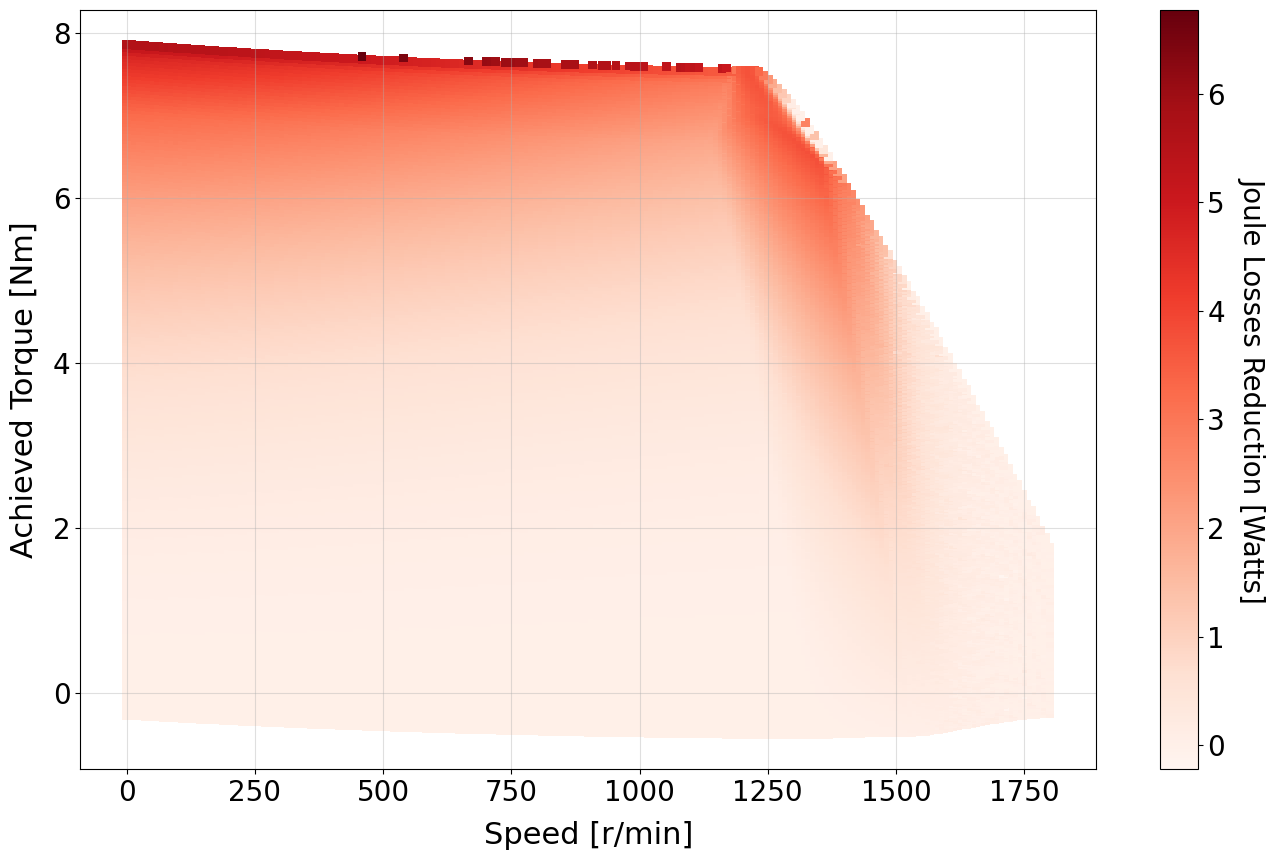

Analysis Complete. Max savings: 6.77 W


In [16]:
plot_joule_losses_reduction(correction_grid, recalc_grid, machine)

## 7. Current trajectories

How do the optimal current sets actually differ between the analytical
and neural views? `plot_current_trajectories_split` plots the DQ
trajectories per harmonic subspace (1st, 3rd, …) for both grids side
by side. The interesting trajectories are the higher harmonics —
that's where the neural model can use injection that the analytical
model didn't predict was useful.

> **Adapting.** This function loops over harmonic subspaces, so a
> 7-phase machine produces 3 rows of plots (harmonics 1, 3, 5) and a
> 9-phase machine produces 4 (harmonics 1, 3, 5, 7).

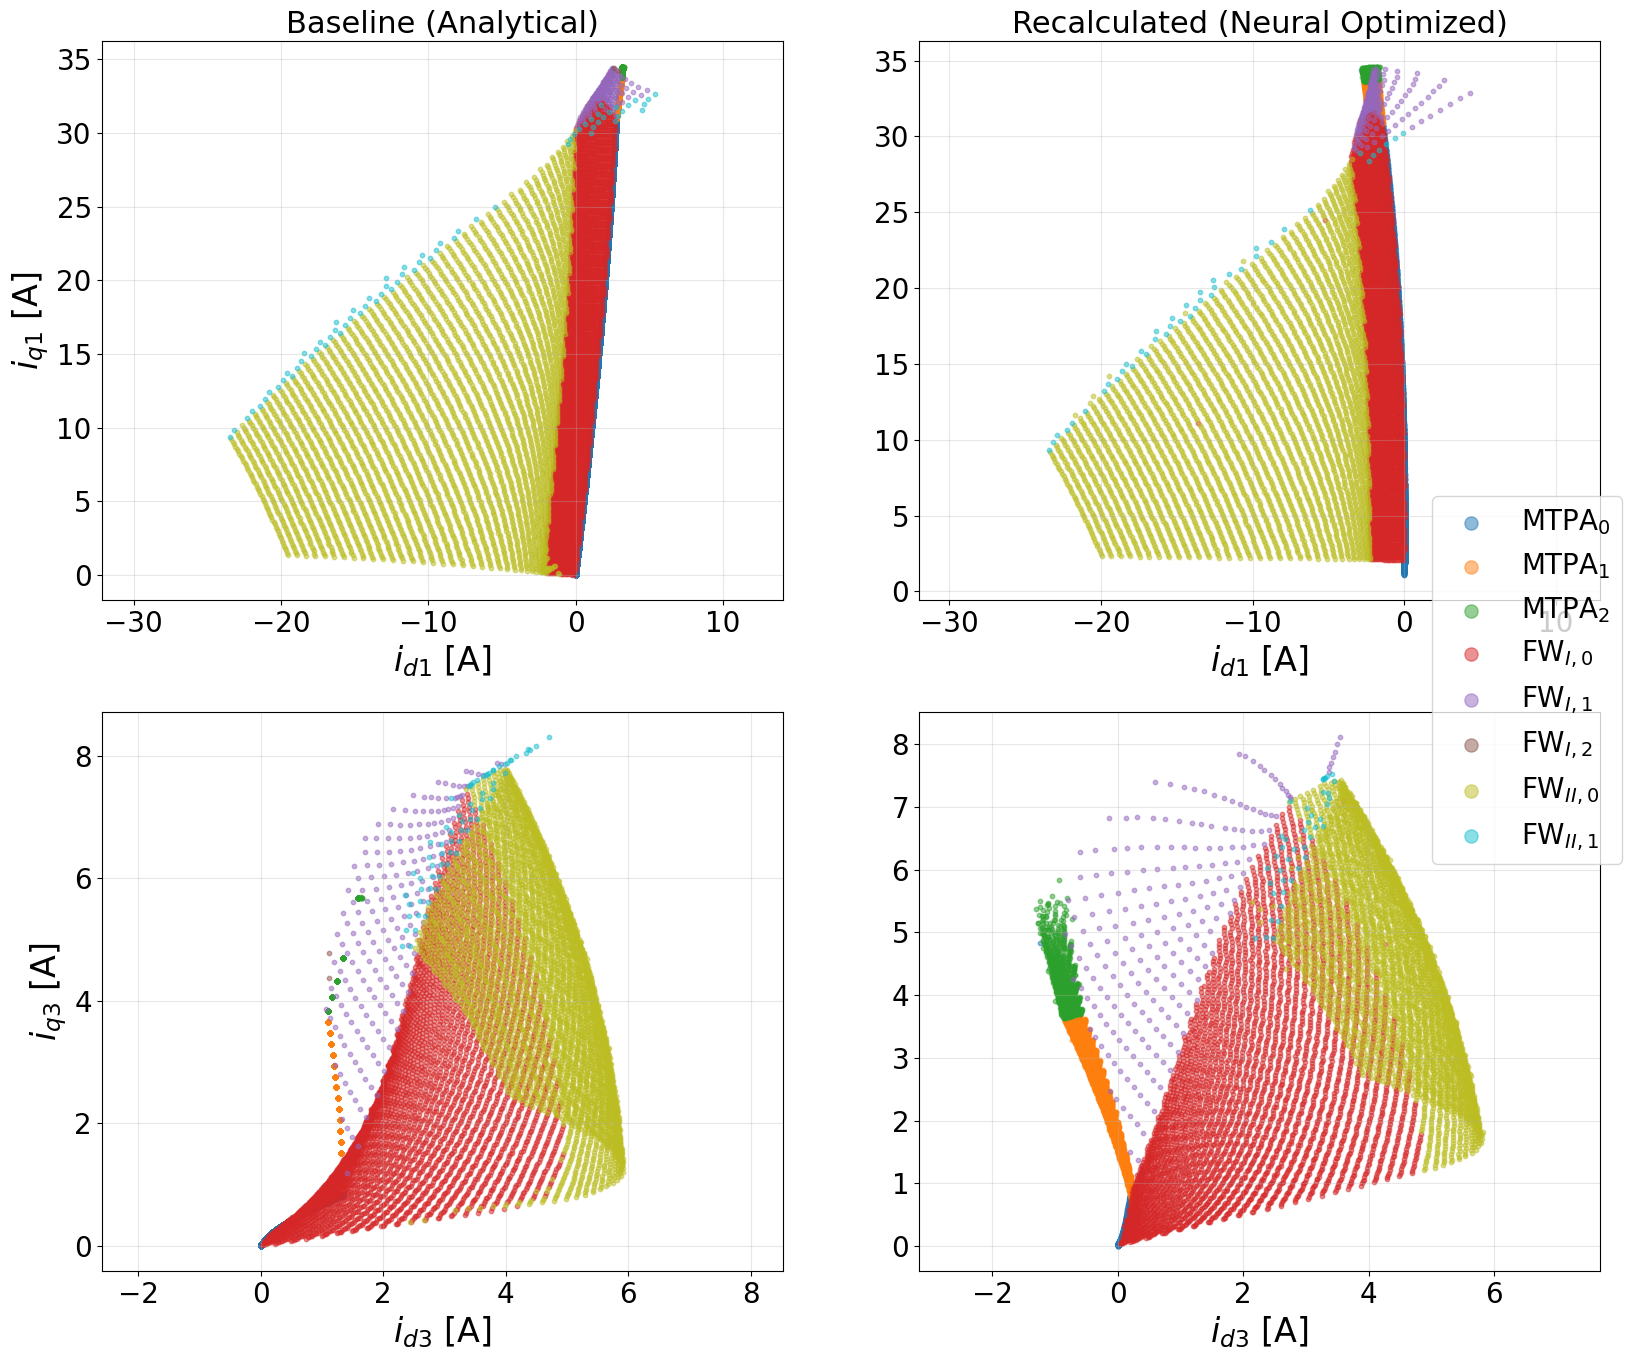

In [17]:
plot_current_trajectories_split(baseline_grid, compensated_grid, machine)

## 8. Validation against measured data

The grids and comparison plots above all live entirely inside the
two models — they don't tell you whether either model actually agrees
with reality. For that we need measured data.

`aggregated_file_means.csv` contains measured torque at known
`(omega, id1, iq1, id3, iq3)` operating points, averaged over multiple
measurement files per condition. We predict torque with both models on
every row, hold out 15% as a test set (matching the train/test split
used during NTM training), and plot predicted vs. measured.

> **Adapting.** The CSV column map and the feature slice
> `X_phys[i, 1:]` are 5-phase-specific. For a 9-phase machine you'd
> add `id5, iq5, id7, iq7` to `COL_MAP` and the column list.

Loaded 174 valid data points from CSV.


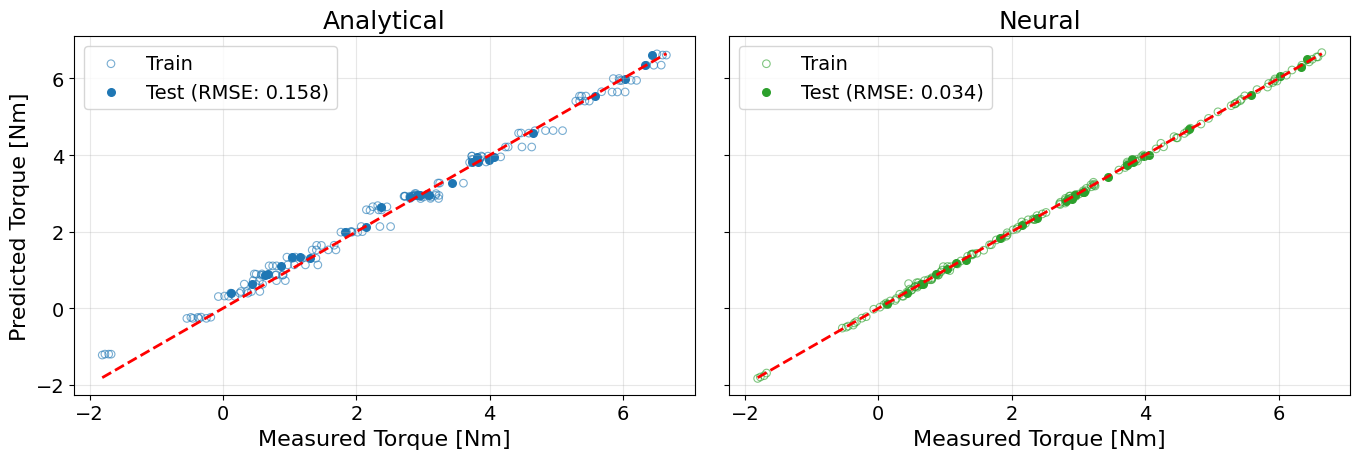

In [18]:
CSV_PATH = os.path.join(data_dir, "aggregated_file_means.csv")
COL_MAP = {
    "omega": "omega",
    "id1": "id1",
    "iq1": "iq1",
    "id3": "id3",
    "iq3": "iq3",
    "torq": "torq_meas",
}

df_meas = load_aggregated_csv_data(CSV_PATH, COL_MAP).reset_index(drop=True)
X_phys = df_meas[["omega", "id1", "iq1", "id3", "iq3"]].to_numpy(dtype=np.float32)

torq_ana_pred = np.zeros(len(X_phys), dtype=np.float64)
torq_neural_pred = np.zeros(len(X_phys), dtype=np.float64)
for i in range(len(X_phys)):
    omega_i = float(X_phys[i, 0])
    i_dq = X_phys[i, 1:].astype(np.float64)
    torq_ana_pred[i] = analytical_model.calculate_torque(omega_i, i_dq)
    torq_neural_pred[i] = neural_model.calculate_torque(omega_i, i_dq)

df_meas["torq_Analytical"] = torq_ana_pred
df_meas["torq_Neural"] = torq_neural_pred
df_meas["Error_Analytical"] = df_meas["torq_meas"] - df_meas["torq_Analytical"]
df_meas["Error_Neural"] = df_meas["torq_meas"] - df_meas["torq_Neural"]

TEST_SIZE = 0.15
RANDOM_STATE = 42
indices = np.arange(len(df_meas))
_, test_idx = train_test_split(
    indices, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
test_mask = np.zeros(len(df_meas), dtype=bool)
test_mask[test_idx] = True

plot_global_performance(df_meas, machine, test_mask=test_mask)

## Wrap-up

That closes the tutorial loop. You've now seen:

1. **Baseline analytical optimization** — minimal viable workflow.
2. **Neural-driven optimization** — same workflow, swapped model.
3. **Comparison and validation** — quantifying the difference and
   sanity-checking both models against measurements.

To apply this library to a different machine, the entry points are
the `BaseMachine` and `Flux` subclasses (see the adaptation notes in
notebook 1). Everything else — `Transform`, `ModelAnalytical`,
`MotorOptimizer`, `calculate_grid`, the plotting functions — is
phase-count agnostic and works as-is.